# Lecture 11: Advanced Architectures and Training Best Practices

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and Python code that implements them, just like you would see in a textbook. In a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
This notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try changing the code that you see**. In many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**.
<br />

### Change everything
Don't feel limited to only changing code when prompted. This notebook is your learning environment and your playground. Try changing and running code throughout the notebook and even **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with, or trying to do is helpful when you revisit it later.
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, you will be asked the same set of questions to elicit your questions, reactions, and feedback. When we review the reading notebook in class, I encourage you to share!

</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Explain when embedding layers are preferable to one-hot encoding for categorical inputs
- Build and reason about residual (skip) connections in deeper networks
- Design multi-branch architectures for heterogeneous business data
- Save and reload models using reliable checkpointing patterns
- Implement early stopping with best-model selection
- Apply regularization choices (weight decay and dropout) based on overfitting behavior
- Build inference pipelines that preserve training-time preprocessing assumptions
- Describe the end-to-end workflow from model training to deployment

In [8]:
# Core imports for this lecture
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Reproducibility for examples
torch.manual_seed(42)
np.random.seed(42)

# 11.1 Advanced Architectures

<img alt="Superman's fortress of solitude" src="../images/L11_architecture_superman.png" width=900 style="display:block;">
<font size=2>Superman gives Lex, Zod and the gang an architecture tour of his fortress of solitude in the Richard Donner cut of <i>Superman II (1980)</i></font>

In this section, you will work with three architecture patterns that appear frequently in applied ML systems: embeddings for categorical signals, residual connections for deeper models, and multi-input branches for combining different data sources. As you read, keep asking: "What business data problem does this pattern solve?"

## Embedding Layers: Handling Categorical Data

Embedding layers transform discrete categorical values (like words, user IDs, or product categories) into continuous vector representations. Think of them as learned lookup tables where each category gets mapped to a dense vector of numbers.

Why are embeddings useful?
- **Dimensionality reduction**: Convert sparse one-hot encodings into compact representations
- **Learned relationships**: The network learns meaningful similarities between categories
- **Efficiency**: Much more memory-efficient than one-hot encoding for large vocabularies

In PyTorch, `nn.Embedding(num_embeddings, embedding_dim)` creates a lookup table with `num_embeddings` items (for example, vocabulary size), each represented as a vector of size `embedding_dim`.

In [2]:
# Create an embedding layer for 100 categories, each mapped to a 16-dimensional vector
embedding = nn.Embedding(num_embeddings=100, embedding_dim=16)

# Category indices (e.g., user IDs, word IDs)
category_ids = torch.tensor([5, 12, 5, 99])  # batch of 4 items

# Look up the embeddings
embedded = embedding(category_ids)
print(f"Input shape: {category_ids.shape}")      # [4]
print(f"Output shape: {embedded.shape}")          # [4, 16]
print(f"\nNotice category 5 appears twice - same embedding both times:")
# note: torch.allclose() checks if two tensors are close within a certain tolerance, which is useful for floating-point comparisons.
print(f"embedding[0]==embedding[2]: {torch.allclose(embedded[0], embedded[2])}") # manually check if embedding for 0th and 2nd item are the same

Input shape: torch.Size([4])
Output shape: torch.Size([4, 16])

Notice category 5 appears twice - same embedding both times:
embedding[0]==embedding[2]: True


Here is what one of the embeddings looks like:

In [3]:
embedded[0]

tensor([ 0.0109, -0.3387, -1.3407, -0.5854,  0.5362,  0.5246,  1.1412,  0.0516,
         0.7440, -0.4816, -1.0495,  0.6039, -1.7223, -0.8278,  1.3347,  0.4835],
       grad_fn=<SelectBackward0>)

Each category index is converted to a learnable vector. Of course, right now that vector doesn't capture anything meaningful, because the model hasn't yet been trained. During training, embedding weights update via backpropagation just like any other model parameter. It is <font color="blue">the training task that confers meaning to embedding vectors</font>. For example, in a product recommendation system, the model might learn that certain products similarly predict consumer behavior, and their embeddings will reflect that similarity.

Embeddings are especially useful for high-cardinality features (product ID, customer ID, merchant ID, text, images, sound). You will revisit this pattern in more depth in later lectures.

## Residual (Skip) Connections: Building Deeper Networks

<img alt="McClane terrifies Zeus with a shortcut through central park" src="../images/L11_diehard3_shortcut.png" width=900 style="display:block;">
<font size=2>"I didn't say park drive. I said through the park." - John McClane, taking Zeus on a shortcut through central park in <i>Die Hard with a Vengeance (1995)</i></font>

One of the most important innovations in deep learning is the **residual connection** (also called a **skip connection**). The idea is simple: instead of only passing data through layers sequentially, we also add a <font color="blue">shortcut that lets the input bypass one or more layers</font>.

The formula is:

$$\text{output} = F(x) + x$$

where $F(x)$ is the transformation from the layer(s), and $x$ is the original input. This means the layer only needs to learn the **residual** - the difference between what came in and what should go out. This type of skip connection is called an **identity skip** (because you multiply the original input by the identity matrix).

More generally, a **projection skip** is used if you want to skip several layers and your original input shape does not match the output shape:

<div style="text-align: center;">
<pre>
   x  ──▶ ... ──▶ F(x)
 │                ▲
 └────────────────┘
    skip 
</pre>
</div>

Because the input $x$ and transformed output $F(x)$ do not have the same shape, you cannot add them directly. You must first pass $x$ through a learnable projection (typically a linear layer, or a $1 \times 1$ convolution in CNNs) to map it to the correct size:

$$\text{output} = F(x) + W_s x$$

This keeps the residual idea intact while allowing skip connections across blocks that change feature dimension (or spatial resolution, in CNNs).

**Why does this help?**
- Makes it easier to train very deep networks (gradients flow through the shortcut)
- At worst, a residual block can learn to do nothing ($F(x) = 0$, so output = $x$)
- This was the key innovation behind **ResNets**, which won the ImageNet competition in 2015

We'll focus only on the simpler **identity skip** case (but when we work with image data and CNNs later, we can try the projection skip).

Let's implement a residual block:

In [4]:
class ResidualBlock(nn.Module):
    """A residual block: the output is F(x) + x"""
    
    def __init__(self, size):
        super().__init__()
        # The transformation F(x)
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Linear(size, size),
            nn.BatchNorm1d(size)
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # The skip connection: add input to the block's output
        residual = x                  # Save the input
        out = self.block(x)           # Transform through the layers
        out = out + residual          # Add the skip connection
        out = self.relu(out)          # Final activation
        return out

In [5]:
# Test it
res_block = ResidualBlock(size=32)
x = torch.randn(8, 32)
y = res_block(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {y.shape}")  # Same shape — key property of residual blocks!
print(f"\nResidual block structure:\n{res_block}")

Input shape:  torch.Size([8, 32])
Output shape: torch.Size([8, 32])

Residual block structure:
ResidualBlock(
  (block): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (relu): ReLU()
)


Notice that the input and output of a residual block have the **same shape**. This is essential — you can't add two tensors of different shapes! This constraint is what makes residual blocks easy to stack.

Let's build a full network that uses residual blocks:

In [6]:
class ResidualMLP(nn.Module):
    """An MLP that uses residual blocks in the middle."""
    
    def __init__(self, input_size, hidden_size, output_size, num_res_blocks=3):
        super().__init__()
        
        # Project input to hidden_size
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU()
        )
        
        # Stack of residual blocks (all same size)
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_size) for _ in range(num_res_blocks)] # note the use of * to unpack here
        )
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.input_layer(x)    # Project to hidden size
        x = self.res_blocks(x)     # Pass through residual blocks
        x = self.output_layer(x)   # Output
        return x

In [7]:
# Create and inspect
res_model = ResidualMLP(input_size=11, hidden_size=64, output_size=1, num_res_blocks=3)
print(res_model)
print(f"\nTotal parameters: {sum(p.numel() for p in res_model.parameters()):,}")

ResidualMLP(
  (input_layer): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=64, out_features=64, bias=True)
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=64, out_features=64, bias=True)
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (2): R

Residual connections are most impactful in deep networks. For shallow networks (2-3 layers), they don't add much. But once you go deeper (5+ layers), they can make the difference between a network that trains well and one that doesn't converge at all.

<!-- Start Exercise 11.1 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 11.1: Build a Network with Residual Connections </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Implement a `WineResNet` class that predicts wine quality using residual connections. Your network should have:

1. An **input projection**: `nn.Linear(11, 32)` followed by ReLU - this brings the 11 input features up to the hidden size used throughout the network
2. **Two residual blocks**, each of size 32. Each block should follow the pattern shown above: two linear layers with batch norm, plus a skip connection that adds the block's input to its output, followed by a final ReLU
3. An **output layer**: `nn.Linear(32, 1)` with no activation

The `ResidualBlock` class is provided as starter code below.

After defining `WineResNet`:
- Create an instance and print it
- Pass a dummy batch of 8 samples through it and verify the output shape is `(8, 1)`
- Print the total parameter count
- Train the model using `train_model()` and plot the training and validation losses

**Think about**: Why does the input projection layer need to exist before the residual blocks? What would happen if you tried to pass the raw 11-feature input directly into a `ResidualBlock(size=32)`?

</div>

WineResNet(
  (input_projection): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
  )
  (res_block1): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU()
  )
  (res_block2): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU()
  )
  (output_layer): Linear(in_features=32, out_features=1,

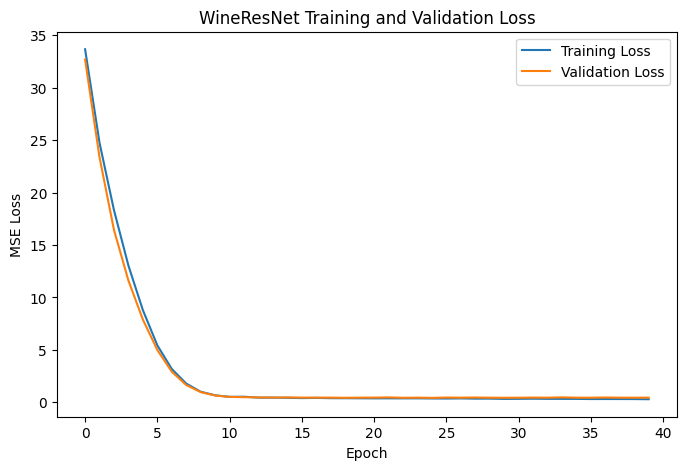

In [10]:
# Exercise 11.1: Build a residual network for wine quality prediction

# Imports, wine data, dataset class, split, dataloaders, residual block definition, and training function are repeated for convenience
# -----------------------------------------------------------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Read wine data and normalize
wine_df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = wine_df.drop('quality', axis=1).values.astype(np.float32)
targets = wine_df['quality'].values.astype(np.float32)
feature_means = features.mean(axis=0)
feature_stds = features.std(axis=0)
features = (features - feature_means) / feature_stds

# WineDataset class
class WineDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features)
        self.targets = torch.tensor(targets).unsqueeze(1)  # (N,) -> (N, 1)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]
        
# Create dataset and split
dataset = WineDataset(features, targets)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Residual block definition
class ResidualBlock(nn.Module):
    """A residual block: output = F(x) + x"""
    def __init__(self, size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Linear(size, size),
            nn.BatchNorm1d(size)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.block(x)
        out = out + residual   # Skip connection
        out = self.relu(out)
        return out

# Training function
def train_model(model, train_loader, val_loader, num_epochs=40, lr=0.001):
    """Train a model and return loss history."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    train_hist = []
    val_hist = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for features_batch, targets_batch in train_loader:
            optimizer.zero_grad()
            pred = model(features_batch)
            loss = loss_fn(pred, targets_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_hist.append(train_loss / len(train_loader))
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features_batch, targets_batch in val_loader:
                pred = model(features_batch)
                loss = loss_fn(pred, targets_batch)
                val_loss += loss.item()
        val_hist.append(val_loss / len(val_loader))
    
    return train_hist, val_hist

#----------------------------------------------------------------------------------------------------------------------------


class WineResNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. Input projection: 11 features -> 32 hidden units
        self.input_projection = nn.Sequential(
            nn.Linear(11, 32),
            nn.ReLU()
        )

        # 2. Two residual blocks of size 32
        self.res_block1 = ResidualBlock(32)
        self.res_block2 = ResidualBlock(32)

        # 3. Output layer: 32 -> 1
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.output_layer(x)
        return x


# Create an instance and print it
model = WineResNet()
print(model)


# Pass a dummy input batch of 8 samples with 11 features
dummy_batch = torch.randn(8, 11)
dummy_output = model(dummy_batch)

print("Dummy output shape:", dummy_output.shape)


# Print total parameter count
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)


# Train the model
train_hist, val_hist = train_model(model, train_loader, val_loader)


# Plot training and validation losses
plt.figure(figsize=(8, 5))
plt.plot(train_hist, label="Training Loss")
plt.plot(val_hist, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("WineResNet Training and Validation Loss")
plt.legend()
plt.show()

You may have noticed that our ResNet did not perform as well as the simple MLP baseline. That is expected here because this dataset is small and the prediction task is relatively simple.

**Q**: Why does the input projection layer need to exist before the residual blocks? What would happen if you tried to pass the raw 11-feature input directly into a `ResidualBlock(size=32)`?

YOUR ANSWER HERE
The input projection layer is needed because the raw wine data has 11 features, but the residual blocks are built to work with 32 features. In a residual block, the model adds the block output back to the original input using the skip connection. That addition only works when both tensors have the same shape. If we passed the raw 11-feature input directly into ResidualBlock(32), the dimensions would not match, so PyTorch would throw a shape error.

<hr/>
<!-- End Exercise 11.1 -->

## Multiple Inputs: Networks that Combine Different Data

Many real business problems combine different sources of information (for example, customer demographics + transaction history, or property attributes + neighborhood indicators). A custom `nn.Module` lets you process each source in a dedicated branch and then merge representations for final prediction:


In [11]:
class MultiInputNet(nn.Module):
    """
    A network that processes two different types of input separately,
    then combines them for prediction.
    
    Example: predicting purchase decision based on customer features and product features.
    """
    
    def __init__(self, num_features_a, num_features_b, hidden_size, output_size):
        super().__init__()
        
        # Separate processing branches
        self.branch_a = nn.Sequential(
            nn.Linear(num_features_a, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),  # we use hidden_size // 2 instead of hidden_size/2 to ensure it's an integer
            nn.ReLU()
        )
        
        self.branch_b = nn.Sequential(
            nn.Linear(num_features_b, hidden_size),  # there's no reason why branch_b has to have the same hidden_size as branch_a, but we'll choose this for our simple example
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU()
        )
        
        # Combined processing after merging branches
        self.combined = nn.Sequential(
            nn.Linear(2 * (hidden_size // 2), hidden_size // 2),  # The combined layer will take the concatenated output from both branches -- need to make sure the dims match!
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size)
        )
    
    def forward(self, input_a, input_b):
        # Process each input through its own branch
        out_a = self.branch_a(input_a)
        out_b = self.branch_b(input_b)
        
        # Concatenate the outputs
        combined = torch.cat([out_a, out_b], dim=1)  # notice dim=1 to concatenate along feature dimension; dim=0 is batch dimension
        
        # Final prediction
        return self.combined(combined)

Let's make a multi-input NN model and test it out with some dummy data:

In [12]:
# Test with two different types of input
model_multi = MultiInputNet(
    num_features_a=5,   # e.g., customer features
    num_features_b=3,   # e.g., product features
    hidden_size=32,
    output_size=1
)

and pass some dummy data through it:

In [13]:
# Simulate data
input_a = torch.randn(8, 5)  # 8 customer/product pairs, 5 customer features
input_b = torch.randn(8, 3)  # 8 customer/product pairs, 3 product features
output = model_multi(input_a, input_b)

print(model_multi)
print(f"\nInput A shape: {input_a.shape}")
print(f"Input B shape: {input_b.shape}")
print(f"Output shape:  {output.shape}")

MultiInputNet(
  (branch_a): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (branch_b): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (combined): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Input A shape: torch.Size([8, 5])
Input B shape: torch.Size([8, 3])
Output shape:  torch.Size([8, 1])


This pattern — separate branches for different data types, then concatenation — is extremely common in production ML systems. It lets each branch learn specialized representations for its data type before combining them.

<!-- Start Exercise 11.2 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 11.2: Design a Network Architecture </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

You're working on a real estate pricing model. You have two types of data:

- **Property features** (8 values): square footage, bedrooms, bathrooms, age, lot size, garage capacity, floors, and condition score
- **Location features** (4 values): school rating, crime index, distance to downtown, walkability score

Design a neural network class called `HousePricePredictor` that:
1. Processes property features through a branch with layers: `8 -> 32 -> 16` with ReLU and dropout (0.2)
2. Processes location features through a branch with layers: `4 -> 16 -> 16` with ReLU and dropout (0.2)
3. Concatenates the two branches (should give 32 features)
4. Passes through a combined layer: `32 -> 16 -> 1` with ReLU (no activation on final output)

Create an instance, print it, and pass dummy data through it to verify the shapes are correct.

</div>

In [15]:
# Exercise 11.2: Design a HousePricePredictor network

# Imports repeated for convenience
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


class HousePricePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Property branch: 8 -> 32 -> 16
        self.property_branch = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Location branch: 4 -> 16 -> 16
        self.location_branch = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Combined layer: 32 -> 16 -> 1
        self.combined = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, property_features, location_features):
        property_out = self.property_branch(property_features)
        location_out = self.location_branch(location_features)
        
        combined_features = torch.cat((property_out, location_out), dim=1)
        
        price_pred = self.combined(combined_features)
        return price_pred
model = HousePricePredictor()
print(model)

property_data = torch.randn(16, 8)
location_data = torch.randn(16, 4)

price_pred = model(property_data, location_data)

print(f"\nProperty input shape:  {property_data.shape}")
print(f"Location input shape:  {location_data.shape}")
print(f"Price prediction shape: {price_pred.shape}")

HousePricePredictor(
  (property_branch): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (location_branch): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (combined): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Property input shape:  torch.Size([16, 8])
Location input shape:  torch.Size([16, 4])
Price prediction shape: torch.Size([16, 1])


<hr/>
<!-- End Exercise 11.2 -->

# 11.2 Training Best Practices

<img alt="Doug and Chappy training" src="../images/L11_training_ironeagle.png" width=900 style="display:block;">
<font size=2>Chappy trains Doug Masters to rescue his dad in <i>Iron Eagle (1986)</i></font>


Strong architecture alone is not enough. In this section, you will focus on practices that improve reliability and generalization: checkpointing, early stopping, and regularization. These are the habits that make models maintainable in real projects, not just in notebooks.

## Model Checkpointing and Saving

Training can take hours or days, so robust saving is a practical requirement. You want to:
- **Protect progress** against crashes or interruptions
- **Deploy trained models** to production environments
- **Share reproducible artifacts** with collaborators
- **Resume training** without losing optimizer state

### The `state_dict()` Pattern

In PyTorch, model parameters are saved through `state_dict()`, which maps layer names to parameter tensors:

```python
# Save model
torch.save(model.state_dict(), 'model.pth')

# Load model
model = MyModel()  # Recreate the same architecture
model.load_state_dict(torch.load('model.pth'))
model.eval()  # Switch to inference behavior if we've loaded it for infeence (or alternatively, use model.train() if we want to continue training)
```

**Important**: The `.pth` file stores weights, not model class code. Recreate the architecture first, then load weights.

### Saving Checkpoints During Training

A **checkpoint** usually includes:
- Model parameters (`model.state_dict()`)
- Optimizer state (`optimizer.state_dict()`)
- Current epoch
- Training/validation metrics

This allows you to restart training from a meaningful state rather than from scratch.

Let's define a simple model and "simulate training" to see how checkpointing works:

In [16]:
# Example: Saving and loading a complete checkpoint

# Ensure save directory exists
os.makedirs('../models', exist_ok=True)

# Simple model for demonstration
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.fc(x)

# Create model and optimizer
model = SimpleNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Simulate some training
epoch = 10
train_loss = 0.45
val_loss = 0.52

Now we are ready to save a checkpoint. We want to keep track of the current epoch, train/validation loss model parameters, and optimizer state. We'll put all of that in a dictionary called `checkpoint` and save it using `torch.save()`:

In [17]:
# Save a complete checkpoint
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss,
    'val_loss': val_loss
}
torch.save(checkpoint, '../models/checkpoint.pth')
print(f"Checkpoint saved at epoch {epoch}")
print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

Checkpoint saved at epoch 10
Train loss: 0.4500, Val loss: 0.5200


Later we can load that checkpoint and resume training from where we left off:

In [18]:
# Load checkpoint to resume training
checkpoint = torch.load('../models/checkpoint.pth')

# We'll need to create a new model and optimizer instance to load the state dicts into
model_resumed = SimpleNet()
optimizer_resumed = optim.Adam(model_resumed.parameters())

# Now we will update the state of our model and optimaizer with the loaded checkpoint data:
model_resumed.load_state_dict(checkpoint['model_state_dict'])
optimizer_resumed.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1

print(f"\nCheckpoint loaded! Ready to resume from epoch {start_epoch}")
print(f"Previous train loss: {checkpoint['train_loss']:.4f}")
print(f"Previous val loss: {checkpoint['val_loss']:.4f}")


Checkpoint loaded! Ready to resume from epoch 11
Previous train loss: 0.4500
Previous val loss: 0.5200


## Early Stopping and Best Model Selection

<img alt="Spaceballs - early stopping" src="../images/L11_early_stopping_spaceballs.png" width=900 style="display:block;">
<font size=2>Dark Helmet experiences "early stopping" when they drop out of Ludicrous Speed in <i>Spaceballs (1987)</i></font>


When training neural networks, validation loss often decreases for a while, then starts increasing again as the model **overfits** to the training data. Continuing to train past this point wastes time and hurts generalization.

**Early stopping** monitors validation loss and stops training when it stops improving:

1. Track the best validation loss seen so far
2. Keep a **patience counter** that increments when validation loss doesn't improve
3. Reset patience when validation loss improves
4. Stop training when patience exceeds a threshold
5. **Save the best model** (lowest validation loss), not the final model

This ensures you return the model with the best generalization, not the most overfitted one.

Let's implement this pattern with the wine quality dataset:

Model has 2,881 parameters

Epoch 1/100 - Train: 31.2619, Val: 28.9209 <- Best model saved!
Epoch 2/100 - Train: 25.6537, Val: 21.6071 <- Best model saved!
Epoch 3/100 - Train: 16.8784, Val: 11.4798 <- Best model saved!
Epoch 4/100 - Train: 7.9434, Val: 4.1200 <- Best model saved!
Epoch 5/100 - Train: 4.5362, Val: 2.6922 <- Best model saved!
Epoch 6/100 - Train: 3.7486, Val: 2.2914 <- Best model saved!
Epoch 7/100 - Train: 3.3612, Val: 2.0003 <- Best model saved!
Epoch 8/100 - Train: 3.2784, Val: 1.8308 <- Best model saved!
Epoch 9/100 - Train: 3.1205, Val: 1.7434 <- Best model saved!
Epoch 10/100 - Train: 2.8633, Val: 1.5849 <- Best model saved!
Epoch 11/100 - Train: 2.9877, Val: 1.5286 <- Best model saved!
Epoch 12/100 - Train: 2.6944, Val: 1.4669 <- Best model saved!
Epoch 13/100 - Train: 2.8241, Val: 1.3691 <- Best model saved!
Epoch 14/100 - Train: 2.6222, Val: 1.3213 <- Best model saved!
Epoch 15/100 - Train: 2.6077, Val: 1.2490 <- Best model saved!
Epoch 16/100 - Train: 2.4873, 

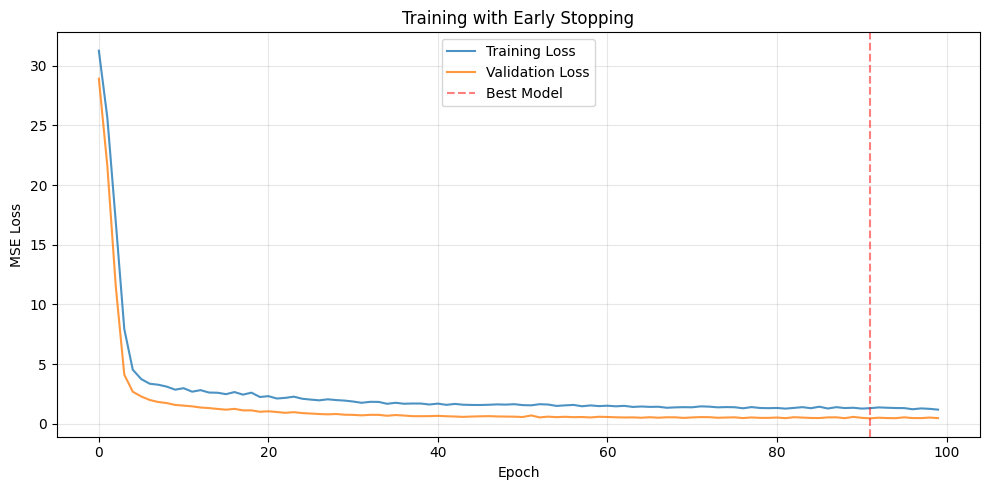


Best validation loss: 0.4615
Final validation loss: 0.4800
Improvement from using best model: 0.0185


In [19]:
# Complete example: Training with early stopping and best model selection


# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Load and preprocess wine data
wine_df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = wine_df.drop('quality', axis=1).values.astype(np.float32)
targets = wine_df['quality'].values.astype(np.float32)

# Normalize features
feature_means = features.mean(axis=0)
feature_stds = features.std(axis=0)
features = (features - feature_means) / feature_stds

# Dataset class
class WineDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features)
        self.targets = torch.tensor(targets).unsqueeze(1)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create dataset and split
dataset = WineDataset(features, targets)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model definition
class WineQualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# HERE is where the early-stopping part is implemented

# Training function with early stopping
def train_with_early_stopping(model, train_loader, val_loader, num_epochs=100, 
                              lr=0.001, patience=10, model_path='../models/best_wine_model.pth'):
    """
    Train with early stopping and save the best model.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Learning rate
        patience: How many epochs to wait for improvement before stopping
        model_path: Where to save the best model
    
    Returns:
        train_hist, val_hist: Loss histories
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    train_hist = []
    val_hist = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    
    for epoch in range(num_epochs):
        # We will train and validate for each epoch, and then check for early stopping based on the best validation loss
        #  seen so far compared to the current epoch's validation loss

        # Training phase
        model.train()
        train_loss = 0.0
        for features_batch, targets_batch in train_loader:
            optimizer.zero_grad()
            pred = model(features_batch)
            loss = loss_fn(pred, targets_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)
        train_hist.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features_batch, targets_batch in val_loader:
                pred = model(features_batch)
                loss = loss_fn(pred, targets_batch)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_hist.append(avg_val_loss)
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            patience_counter = 0
            # Save the best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'train_loss': avg_train_loss
            }, model_path)
            print(f"Epoch {epoch+1}/{num_epochs} - Train: {avg_train_loss:.4f}, "
                  f"Val: {avg_val_loss:.4f} <- Best model saved!")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1}/{num_epochs} - Train: {avg_train_loss:.4f}, "
                  f"Val: {avg_val_loss:.4f} (patience: {patience_counter}/{patience})")
            
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                print(f"Best model was from epoch {best_epoch+1} with val loss: {best_val_loss:.4f}")
                break
    
    return train_hist, val_hist

# Create model and train
model = WineQualityNet()
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters\n")

train_hist, val_hist = train_with_early_stopping(
    model, 
    train_loader, 
    val_loader,
    num_epochs=100,
    lr=0.001,
    patience=10,
    model_path='../models/best_wine_model.pth'
)

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_hist, label='Training Loss', alpha=0.8)
plt.plot(val_hist, label='Validation Loss', alpha=0.8)
plt.axvline(x=val_hist.index(min(val_hist)), color='red', linestyle='--', 
            alpha=0.5, label='Best Model')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training with Early Stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest validation loss: {min(val_hist):.4f}")
print(f"Final validation loss: {val_hist[-1]:.4f}")
print(f"Improvement from using best model: {val_hist[-1] - min(val_hist):.4f}")

### Regularization: Preventing Overfitting

<img alt="Madonna had no regularization" src="../images/L11_overfitting_madonna.png" width=900 style="display:block;">
<font size=2>The entire 80s are probably guilty of "overfitting", as Madonna demonstrates in <i>Desperately Seeking Susan (1985)</i></font>


We've already seen **dropout** in previous lectures. Let's compare it with another important regularization technique: **weight decay**.

**Weight decay** (also called L2 Regularization) adds a penalty to large weights during optimization. Mathematically, it is equivalent to adding a term to the loss function that penalizes weights of large magnitude:

$$L_{total} = L_{task} + \lambda \sum w_i^2$$

where $\lambda$ is the weight decay coefficient (typically 1e-4 to 1e-2).

In PyTorch, you can enable it via the optimizer:

```python
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
```

Which one should you use and when?

| Technique | How it works | When to use |
|-----------|--------------|-------------|
| **Dropout** | Randomly zeros neurons during training | Deep networks, when you have enough data, works well with larger models |
| **Weight Decay** | Penalizes large weights | Strong default in many settings, especially useful with smaller datasets |

**Best practice**: Caerfully select your model architecture to have sufficient capacity for your task using real-world comparisons and benchmarks. Build dropout layers into your network where appropriate and use an optimizer that supports weight decay. When training, focus on performance (leave dropout and weight decay at zero), but track your validation loss for signs of overfitting. If you see low training loss and high validation loss, you may be overfitting. Introduce regularization by start with low weight decay (e.g., 0.01), then add dropout to dense layers if the problem persists. Increase regularization strength as needed.


## 11.3 Inference Patterns

After training your model, you need to **deploy** it for making predictions on new data. This process is called **inference** or **prediction**. Getting inference right is critical for production systems.

### Inference Checklist

When moving from training to deployment, use this checklist every time:

1. **Set evaluation mode**: Call `model.eval()` to disable dropout and use stored batch-norm statistics

2. **Disable gradient tracking**: Use `torch.no_grad()` for lower memory use and faster inference

3. **Match preprocessing exactly**: Apply the same normalization/feature logic used during training

4. **Validate shapes and batching**: Ensure single examples are converted to batch format when needed

These details look small, but they are common causes of production prediction bugs.

Let's follow the typical inference workflow, where you already have a trained model that is saved as a checkpoint, but you need to recreate the architecture, load the weights, and prepare it for inference:

In [20]:
# Complete inference workflow

# Step 1: Define the model architecture (must match training!)
class WineQualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [21]:
# Step 2: Load the saved model
model = WineQualityNet()
checkpoint = torch.load('../models/best_wine_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # CRITICAL: Set to evaluation mode

print("Model loaded successfully!")
print(f"This model was saved at epoch {checkpoint['epoch']+1}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}\n")

Model loaded successfully!
This model was saved at epoch 92
Validation loss: 0.4615



In [22]:
# Step 3: Load preprocessing statistics (must match training!)
wine_df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = wine_df.drop('quality', axis=1).values.astype(np.float32)
feature_means = features.mean(axis=0)
feature_stds = features.std(axis=0)

print("Preprocessing statistics loaded\n")

Preprocessing statistics loaded



Now we're ready to make some predictions (presumably on new data, but here we'll just use dummy data):

In [23]:
# Step 4: Inference on a single new sample
def predict_wine_quality(model, wine_features, feature_means, feature_stds):
    """
    Predict wine quality for a single wine sample.
    
    Args:
        model: Trained PyTorch model in eval mode
        wine_features: Array of 11 wine features (unnormalized)
        feature_means: Mean values from training data
        feature_stds: Std values from training data
    
    Returns:
        Predicted quality score
    """
    # Preprocess: Apply same normalization as training
    wine_normalized = (wine_features - feature_means) / feature_stds
    
    # Convert to tensor and add batch dimension
    wine_tensor = torch.tensor(wine_normalized, dtype=torch.float32).unsqueeze(0)
    
    # Inference with gradient tracking disabled
    with torch.no_grad():
        prediction = model(wine_tensor)
    
    return prediction.item()

In [24]:
# Example: Predict quality for a new wine
new_wine = np.array([
    7.4,   # fixed acidity
    0.70,  # volatile acidity
    0.00,  # citric acid
    1.9,   # residual sugar
    0.076, # chlorides
    11.0,  # free sulfur dioxide
    34.0,  # total sulfur dioxide
    0.9978,# density
    3.51,  # pH
    0.56,  # sulphates
    9.4    # alcohol
])

predicted_quality = predict_wine_quality(model, new_wine, feature_means, feature_stds)
print(f"Single wine prediction:")
print(f"Predicted quality: {predicted_quality:.2f}")

Single wine prediction:
Predicted quality: 5.24


In many cases, you want to run prediction on a whole batch of new data, not a single example:

In [25]:
# Batch inference (more efficient for multiple samples)
def predict_wine_quality_batch(model, wine_features_batch, feature_means, feature_stds):
    """
    Predict wine quality for multiple samples at once.
    
    Args:
        wine_features_batch: Array of shape (N, 11) with N wine samples
    
    Returns:
        Array of N predictions
    """
    # Normalize all samples
    normalized = (wine_features_batch - feature_means) / feature_stds
    
    # Convert to tensor (already has batch dimension)
    batch_tensor = torch.tensor(normalized, dtype=torch.float32)
    
    # Batch inference
    with torch.no_grad():
        predictions = model(batch_tensor)
    
    return predictions.squeeze().numpy()

# Example: Predict for multiple wines
sample_wines = features[:5]  # First 5 wines from dataset
actual_qualities = wine_df['quality'].values[:5]

batch_predictions = predict_wine_quality_batch(model, sample_wines, feature_means, feature_stds)

print(f"\nBatch inference (5 wines):")
print(f"{'Predicted':<12} {'Actual':<12} {'Error':<12}")
print("-" * 36)
for pred, actual in zip(batch_predictions, actual_qualities):
    error = abs(pred - actual)
    print(f"{pred:<12.2f} {actual:<12.0f} {error:<12.2f}")

mae = np.mean(np.abs(batch_predictions - actual_qualities))
print(f"\nMean Absolute Error: {mae:.3f}")


Batch inference (5 wines):
Predicted    Actual       Error       
------------------------------------
5.24         5            0.24        
5.13         5            0.13        
5.16         5            0.16        
5.37         6            0.63        
5.24         5            0.24        

Mean Absolute Error: 0.280


### Batch vs Single Inference


**Single inference** (one sample at a time):
- Real-time API endpoints
- Interactive applications
- When latency matters more than throughput

**Batch inference** (many samples at once):
- Offline processing of large datasets
- When throughput matters more than latency
- More efficient: better GPU utilization

### Production Deployment Patterns

#### Pattern 1: REST API for Real-Time Inference
```python
# Example Flask API (pseudocode)
from flask import Flask, request, jsonify

app = Flask(__name__)
model = load_model()  # Load once at startup
model.eval()

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json['features']
    # Preprocess and predict
    prediction = predict_wine_quality(model, data, means, stds)
    return jsonify({'quality': prediction})
```

#### Pattern 2: Batch Processing Pipeline
```python
# Process large CSV files in batches
def process_csv(input_path, output_path, batch_size=256):
    model.eval()
    
    df = pd.read_csv(input_path)
    predictions = []
    
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i+batch_size]
        batch_pred = predict_wine_quality_batch(model, batch.values, means, stds)
        predictions.extend(batch_pred)
    
    df['predicted_quality'] = predictions
    df.to_csv(output_path, index=False)
```

#### Pattern 3: Export to ONNX for Production
**ONNX** (Open Neural Network Exchange) is an open standard format for representing ML models. Once exported to ONNX, your model can be run by any compatible runtime — in C++, JavaScript, on mobile devices, or in cloud services — without needing Python or PyTorch installed.

```python
# Export to ONNX
dummy_input = torch.randn(1, 11)
torch.onnx.export(model, dummy_input, 'wine_model.onnx')
```

### Key Takeaways for Inference

1. Always use `model.eval()` and `torch.no_grad()`
2. Preprocessing must exactly match training
3. Save preprocessing statistics with your model
4. Choose single vs batch inference based on your use case
5. Consider ONNX export for production deployment

<!-- Start Exercise 11.3 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 11.3: Debug a Broken Inference Pipeline </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

A colleague has written an inference function, but it contains **three "bugs"** — not all technically bugs, but certainly all violations of the inference checklist you just read. Your job is to find and fix them.

**Part 1**: Run the setup cell below. It trains a small wine quality model, then calls the broken inference function **twice on the exact same wine sample**. Look carefully at the output.

**Part 2**: In the fix cell that follows, implement `predict_wine_fixed()` with all three bugs corrected, then verify your fix produces consistent, reasonable predictions.

**Hints to guide your debugging**:
- Why do two calls with *identical input* return *different values*?
- How far off are the broken predictions from the actual quality score? Does that seem right for a trained model?
- Re-read the inference checklist above this exercise.

</div>

In [26]:
# Exercise 11.3 Setup — run this cell, then look closely at the output
# (All dependencies are self-contained below)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# --- Load and normalize wine data ---
wine_df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = wine_df.drop('quality', axis=1).values.astype(np.float32)
labels   = wine_df['quality'].values.astype(np.float32)

ex_means = features.mean(axis=0)
ex_stds  = features.std(axis=0)

X = torch.tensor((features - ex_means) / ex_stds, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

# --- Small model with dropout ---
class ExWineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

ex_model = ExWineNet()
optimizer = optim.Adam(ex_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Quick training — full-batch, enough to learn the signal
ex_model.train()
for ep in range(60):
    optimizer.zero_grad()
    loss = criterion(ex_model(X), y)
    loss.backward()
    optimizer.step()

print(f"Training complete. Final loss: {loss.item():.4f}\n")

# --- Broken inference function (contains 3 bugs) ---
def predict_wine_fixed(model, wine_features, feature_means, feature_stds):
    """Run inference on a single wine sample and return the predicted quality."""
    
    # 1. Put model in evaluation mode
    model.eval()
    
    # 2. Normalize correctly: subtract mean AND divide by std
    normalized = (wine_features - feature_means) / feature_stds
    
    # 3. Convert to tensor and add batch dimension
    input_tensor = torch.tensor(normalized, dtype=torch.float32).unsqueeze(0)
    
    # 4. Turn off gradient tracking for inference
    with torch.no_grad():
        prediction = model(input_tensor)
    
    return prediction.item()

Training complete. Final loss: 1.4164



In [28]:
# Exercise 11.3: Fix the broken inference function
# Implement predict_wine_fixed() with all three bugs corrected.
# Your fixed version should return the same value on repeated calls
# and produce predictions in a reasonable range for wine quality (3–8).

def predict_wine_fixed(model, wine_features, feature_means, feature_stds):
    """Fixed inference function — correct all three bugs from predict_wine_broken()."""
    
    # Put model in evaluation mode
    model.eval()
    
    # Proper normalization
    normalized = (wine_features - feature_means) / feature_stds
    
    # Convert to tensor and add batch dimension
    input_tensor = torch.tensor(normalized, dtype=torch.float32).unsqueeze(0)
    
    # Disable gradient tracking
    with torch.no_grad():
        prediction = model(input_tensor)
    
    return prediction.item()

sample = features[0]
actual = labels[0]
# --- Verify your fix ---
pred_fixed1 = predict_wine_fixed(ex_model, sample, ex_means, ex_stds)
pred_fixed2 = predict_wine_fixed(ex_model, sample, ex_means, ex_stds)

print(f"Actual quality:        {actual:.1f}")
print(f"Fixed prediction 1:    {pred_fixed1}")
print(f"Fixed prediction 2:    {pred_fixed2}")
print(f"Same result both calls? {pred_fixed1 is not None and abs(pred_fixed1 - pred_fixed2) < 0.001}")

Actual quality:        5.0
Fixed prediction 1:    5.457326412200928
Fixed prediction 2:    5.457326412200928
Same result both calls? True


<hr/>
<!-- End Exercise 11.3 -->

## Summary

In this lecture, you connected architecture choices with operational training and inference practices that matter in applied ML work.

### Key Takeaways

**Advanced Architectures:**
- **Embedding layers** map categorical inputs into dense learned representations and scale better than one-hot encoding for high-cardinality features
- **Residual connections** improve optimization in deeper networks by giving gradients shorter paths
- **Multiple input branches** let you model heterogeneous business data using specialized pathways before fusion

**Training Best Practices:**
- **Checkpointing** preserves progress and enables reproducible recovery
- **Early stopping** helps you select a better-generalizing model instead of simply the final epoch
- **Regularization** (weight decay and dropout) helps control overfitting when model capacity exceeds data signal

**Inference Patterns:**
- Use `model.eval()` and `torch.no_grad()` consistently
- Keep preprocessing logic identical between training and inference
- Choose single-sample vs batch prediction based on latency vs throughput needs
- Consider ONNX export when portability across runtimes is a priority

### End-to-End Workflow

1. **Design**: Choose architecture based on data modality and task
2. **Train**: Monitor validation performance and apply regularization
3. **Select**: Keep the best checkpoint, not just the last epoch
4. **Deploy**: Recreate preprocessing and run in evaluation mode
5. **Operate**: Serve predictions with the right inference pattern for the business context

These habits are core to building dependable ML systems in practice.

## Reflection Questions

Think about the following as you reflect on this lecture:

1. **Architecture decisions**: When would you choose to use residual connections? When might they be unnecessary overhead?

2. **Training strategies**: How do you decide the right patience value for early stopping? What are the tradeoffs of being too conservative vs too aggressive?

3. **Regularization choices**: You have a model that's overfitting. How do you decide whether to add more dropout, increase weight decay, get more data, or reduce model capacity?

4. **Preprocessing consistency**: What could go wrong if your inference preprocessing doesn't exactly match training? Can you think of a specific example scenario?

5. **Production considerations**: Your model needs to make predictions for a real-time web application. What are the key performance considerations beyond just accuracy?

6. **Multiple inputs**: Can you think of a business problem where combining multiple types of data (numerical, categorical, text, images) through separate branches would be valuable?

Write your thoughts below or discuss with your classmates.

**Your reflection:**

[Write your thoughts here]
1) Residual connections are most useful in deeper neural networks because they help information and gradients flow through the model more easily, reducing issues like vanishing gradients. They are especially helpful when a model has many layers and starts becoming harder to train. For smaller or simpler models, residual connections can sometimes be unnecessary overhead because the network may already train well without them.

2) The right patience value for early stopping depends on how noisy the validation loss is and how quickly the model learns. A patience value that is too small may stop training before the model fully improves, while a value that is too large may allow overfitting and waste computation time. Usually, you experiment with different values and monitor validation performance trends.

3) If a model is overfitting, the best fix depends on the situation. Adding dropout or weight decay can help regularize the model, while reducing model capacity may help if the network is too complex for the dataset. Getting more data is often the strongest solution because it improves generalization naturally. I would usually start with regularization methods before redesigning the whole architecture.

4) If inference preprocessing does not match training preprocessing, the model may receive inputs in a completely different scale or format than what it learned from. This can cause inaccurate or unstable predictions. For example, if a wine quality model was trained on normalized features but raw values were used during inference, predictions could become unrealistic because the model expects standardized inputs.

5) For a real-time web application, important considerations include inference speed, memory usage, scalability, reliability, and consistency of predictions. A highly accurate model may still be impractical if it is too slow or expensive to run in production. Monitoring latency and ensuring the model can handle many users at once are also important.

6) A good example would be an online shopping recommendation system. Numerical data like price and ratings, categorical data like product category, text data from reviews, and image data from product photos could all be processed through separate branches of a neural network. Combining these inputs would help the model better understand both the product and user preferences, leading to more accurate recommendations.

